In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

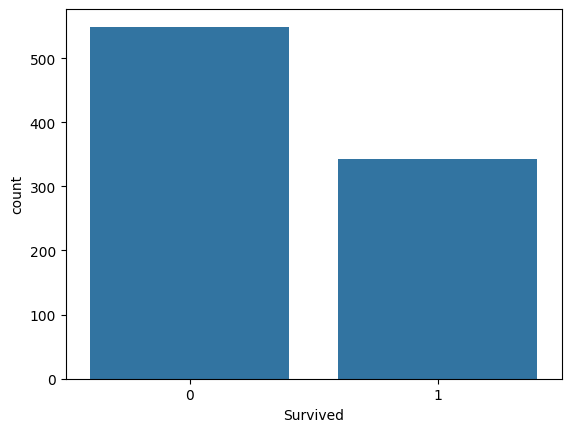

In [10]:
sns.countplot(x='Survived',data=df)

<Axes: >

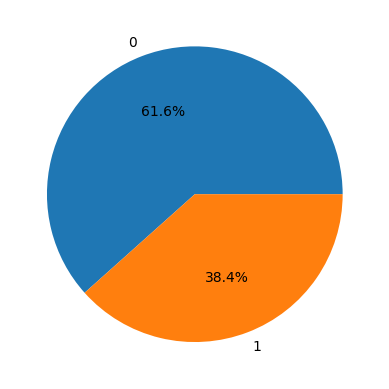

In [11]:
df['Survived'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='Age', ylabel='Count'>

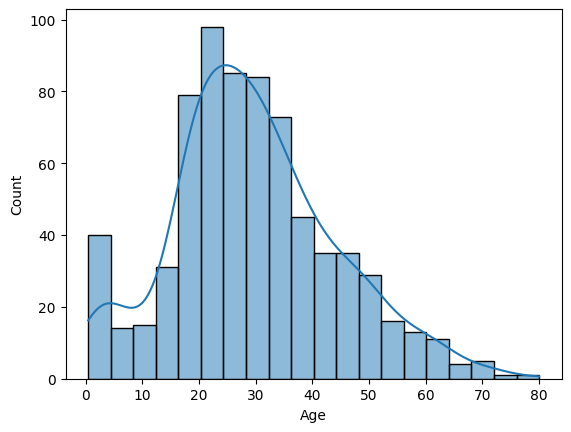

In [12]:
sns.histplot(df['Age'],kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

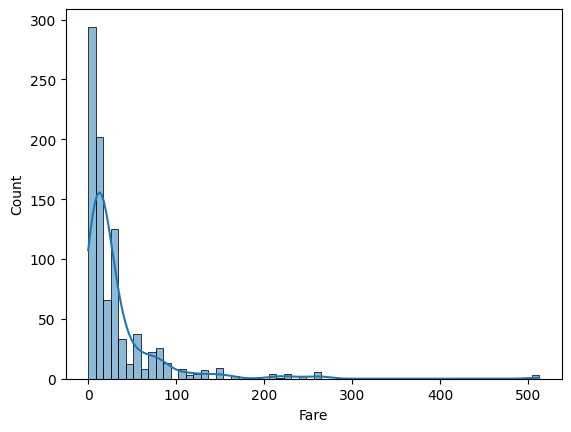

In [13]:
sns.histplot(df['Fare'],kde=True)

<Axes: ylabel='Fare'>

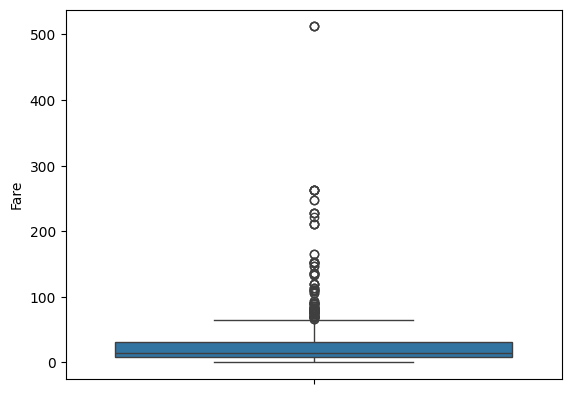

In [14]:
sns.boxplot(df['Fare'])

<Axes: xlabel='Pclass', ylabel='count'>

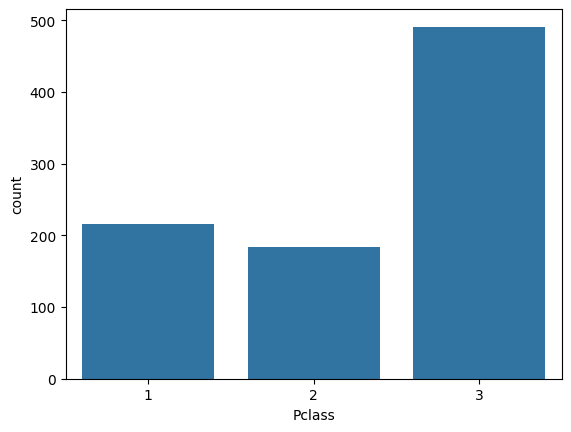

In [15]:
sns.countplot(x='Pclass',data=df)

<Axes: xlabel='Sex', ylabel='count'>

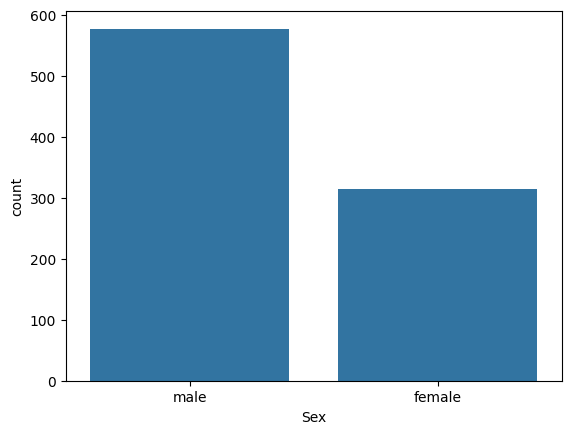

In [16]:
sns.countplot(x='Sex',data=df)

<Axes: xlabel='Sex', ylabel='Survived'>

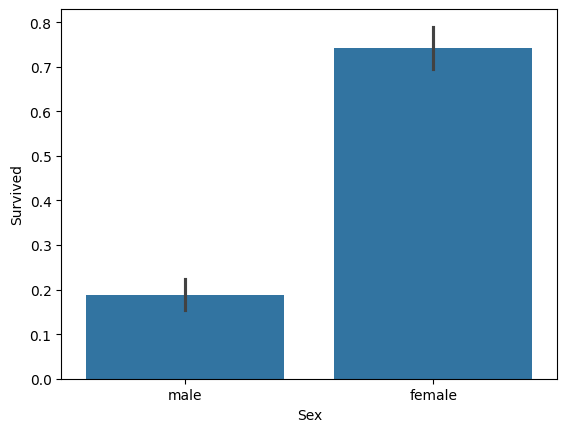

In [17]:
# plt.figure(figsize=(6,10))
sns.barplot(x='Sex',y='Survived',data=df)

<Axes: xlabel='Pclass', ylabel='Survived'>

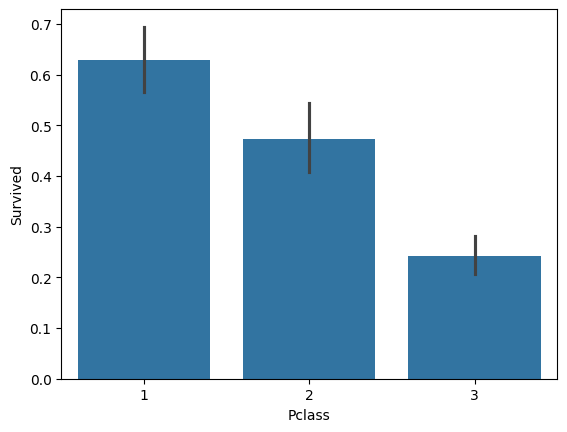

In [18]:
sns.barplot(x='Pclass',y='Survived',data=df)

In [19]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

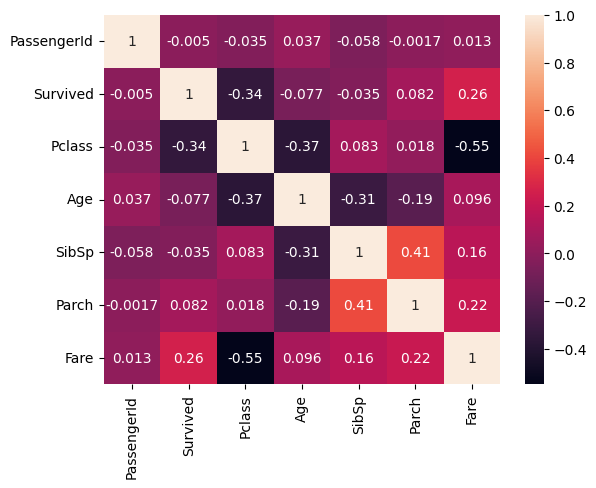

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [21]:
pclass_anaylsis = pd.DataFrame(df.groupby('Pclass')['Survived'].value_counts())
pclass_anaylsis

count
Pclass Survived       
1      1           136
       0            80
2      0            97
       1            87
3      0           372
       1           119

In [22]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

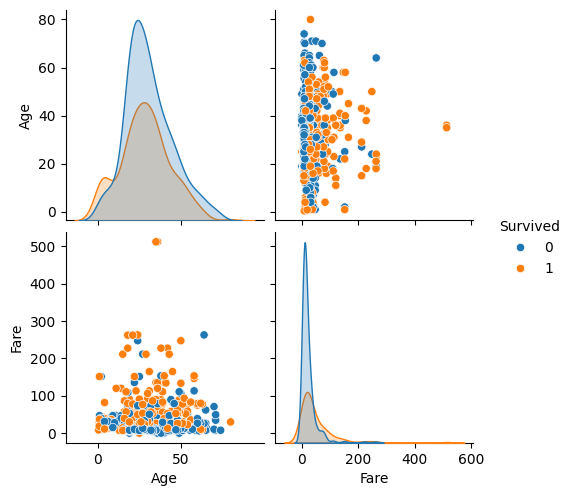

In [23]:
sns.pairplot(df[['Age','Fare','Survived']],hue='Survived')

<Axes: xlabel='Age', ylabel='Fare'>

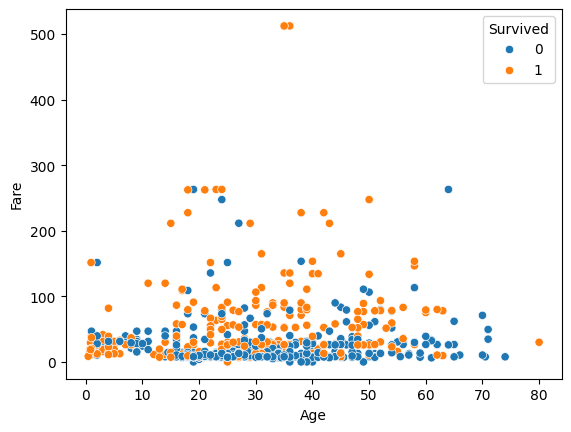

In [24]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df)

In [25]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [26]:
# percentage
pd.crosstab(df['Pclass'], df['Survived'], normalize='index')

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


# Chi - Sqaure for Pclass and Survived yto test there are independent or not.

*Null Hypothesis :* Passenger class and survival are independent.


*Alternate Hypothesis :* Passenger class and survival are dependent.

In [27]:
table = pd.crosstab(df['Pclass'],df['Survived'])
table

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [28]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print('Chi2 Value :', chi2)
print('p value :', p)
print('dof :',dof)
print('excepted : ', expected)

Chi2 Value : 102.88898875696056
p value : 4.549251711298793e-23
dof : 2
excepted :  [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


## conclusion 

*Pclass significantly affect the Survival*

In [30]:
table = pd.crosstab(df['Sex'],df['Survived'])

table

Survived,0,1
Sex,,
female,81,233
male,468,109


In [31]:
chi2, p, dof, expected = chi2_contingency(table)
print('Chi2 Value :', chi2)
print('p value :', p)
print('dof :',dof)
print('excepted : ', expected)

Chi2 Value : 260.71702016732104
p value : 1.1973570627755645e-58
dof : 1
excepted :  [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


## conclusion 

*Sex significant affect the survival*

In [33]:
table = pd.crosstab(df['Embarked'], df['Survived'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

1.769922284120912e-06


In [32]:
from scipy.stats import ttest_ind

survived = df[df['Survived'] == 1]['Age'].dropna()
not_survived = df[df['Survived'] == 0]['Age'].dropna()

t_stat , p = ttest_ind(survived,not_survived)

print(t_stat)
print(p)


# H0: mean age same for survivors and non-survivors
# hence the mean differs

-2.06668694625381
0.039124654013482474


In [34]:
survived = df[df['Survived']==1]['Fare']
dead = df[df['Survived']==0]['Fare']

t_stat, p = ttest_ind(survived, dead)

print(p)

# Hence you had payed more they survived


6.1201893419242075e-15


In [35]:
from scipy.stats import f_oneway


class1 = df[df['Pclass']==1]['Fare']
class2 = df[df['Pclass']==2]['Fare']
class3 = df[df['Pclass']==3]['Fare']

f_stat, p = f_oneway(class1, class2, class3)

print(p)
# H0: mean fare same across classes
# Hence the fare are different across the Pclass.



1.031376320913912e-84


In [36]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1

df['family_size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64

In [37]:
table = pd.crosstab(df['family_size'], df['Survived'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

# Hence survival is also depended on family size

3.579668975443533e-14


In [47]:
from scipy.stats import pearsonr

temp = df[['Age','Fare']].dropna()

corr, p = pearsonr(temp['Age'], temp['Fare'])

print(corr, p)

0.0960666917690389 0.010216277504447018


In [44]:
df[['Age','Survived']].corr()

,Age,Survived
Age,1.000000,-0.077221
Survived,-0.077221,1.000000
